# Model Explainability

최종 예측 모델인 XGBoost의 예측 결과를 해석하기 위해
SHAP(SHapley Additive exPlanations)을 사용한다.

모델 성능만 비교하는 것이 아니라,
각 Feature가 가격 예측에 얼마나 기여하는지 분석한다.

## 분석 목표

### 전세 모델
- 어떤 변수가 전세가격 예측에 가장 큰 영향을 미치는가?
- 면적, 지역, 건축연식은 모델에서 어떤 중요도를 가지는가?
- 특정 계약의 높은 또는 낮은 예측가격은 어떤 Feature 때문에 결정되는가?

### 월세 모델
- 보증금이 월세 예측에 미치는 영향은 어느 정도인가?
- 지역 및 주택 특성의 영향은 어떻게 나타나는가?

전체 Test 데이터를 SHAP으로 계산하면 연산량이 매우 크기 때문에
대표 표본을 추출하여 모델의 전반적인 예측 패턴을 분석한다.

In [8]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

MODEL_DATA_DIR = Path("../data/processed/modeling")
MODEL_DIR = Path("../models")

In [2]:
jeonse_model = joblib.load(
    MODEL_DIR / "jeonse_xgboost.joblib"
)

jeonse_test = pd.read_csv(
    MODEL_DATA_DIR / "jeonse_test.csv",
    parse_dates=["contract_date"]
)

print("Test:", jeonse_test.shape)
print("Model:", type(jeonse_model))

Test: (238570, 11)
Model: <class 'sklearn.pipeline.Pipeline'>


In [3]:
jeonse_features = [
    "자치구명",
    "법정동명",
    "임대면적",
    "building_age",
    "층",
    "time_idx",
    "contract_month_sin",
    "contract_month_cos"
]

X_shap = jeonse_test[
    jeonse_features
].sample(
    n=5000,
    random_state=42
)

print(X_shap.shape)

(5000, 8)


In [4]:
preprocessor = jeonse_model.named_steps[
    "preprocessor"
]

xgb_estimator = jeonse_model.named_steps[
    "model"
]

X_shap_transformed = preprocessor.transform(
    X_shap
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "변환 데이터:",
    X_shap_transformed.shape
)

print(
    "Feature 개수:",
    len(feature_names)
)

변환 데이터: (5000, 356)
Feature 개수: 356


## 전세 모델 SHAP 분석

최종 XGBoost 모델이 전세가격을 예측할 때
각 Feature가 예측값에 얼마나 기여하는지 SHAP을 이용해 분석한다.

범주형 변수는 One-Hot Encoding을 거쳐 여러 Feature로 변환되므로,
먼저 변환된 개별 Feature의 중요도를 확인한 뒤
추후 원래 변수 단위로도 중요도를 통합하여 해석한다.

전세 모델은 `log(전세보증금)`을 예측하도록 학습되었기 때문에
SHAP 값 역시 기본적으로 로그 예측값 공간에서의 기여도를 의미한다.

In [5]:
explainer = shap.TreeExplainer(
    xgb_estimator
)

shap_values = explainer.shap_values(
    X_shap_transformed
)

print(
    "SHAP values shape:",
    shap_values.shape
)

SHAP values shape: (5000, 356)


In [6]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(
        shap_values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(20)

,feature,mean_abs_shap
0,num__임대면적,0.263602
1,num__building_age,0.132054
2,num__time_idx,0.066246
3,cat__자치구명_강남구,0.061469
4,cat__자치구명_서초구,0.040407
5,cat__자치구명_노원구,0.031027
6,num__층,0.024437
7,cat__자치구명_송파구,0.017584
8,cat__자치구명_도봉구,0.016041
9,cat__자치구명_구로구,0.014333


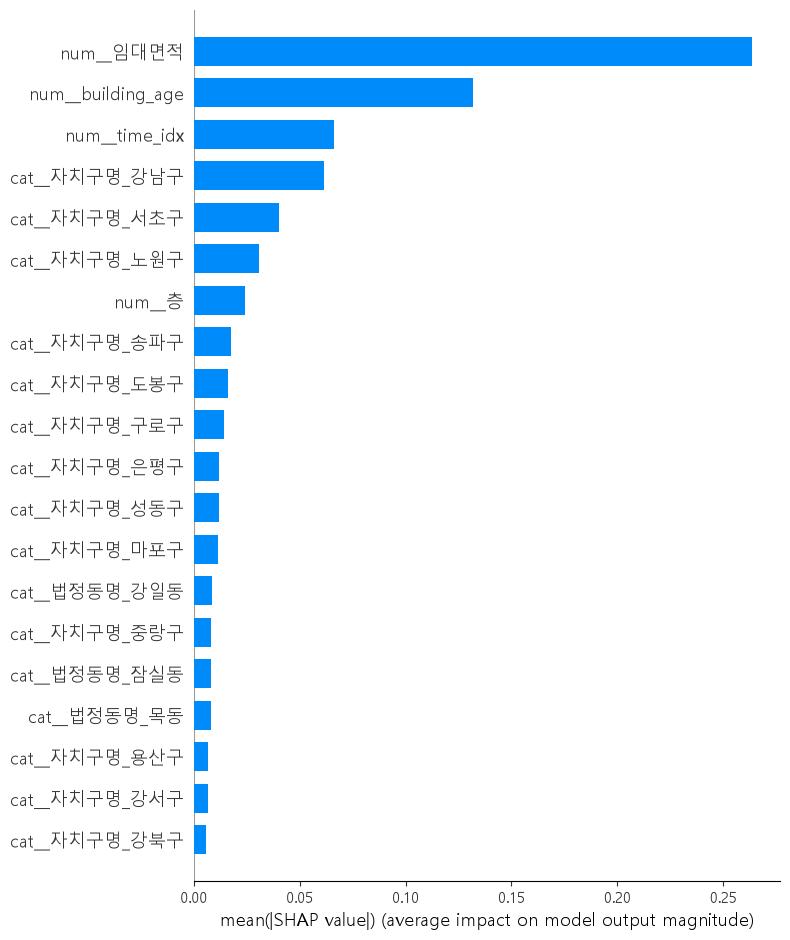

In [9]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=True
)

## 원래 변수 단위 SHAP 중요도

One-Hot Encoding으로 인해 자치구와 법정동이
여러 개의 개별 Feature로 분리되어 있다.

모델의 전체적인 영향력을 더 직관적으로 해석하기 위해
같은 원본 변수에서 생성된 SHAP 값을 다시 합산하여
원래 Feature 단위의 중요도를 계산한다.

범주형 Feature는 각 관측치에서 파생된 One-Hot Feature들의
SHAP 값을 먼저 합산한 뒤 절댓값 평균을 계산한다.

In [10]:
feature_names = np.array(feature_names)

feature_groups = {
    "자치구명": np.where(
        np.char.startswith(
            feature_names.astype(str),
            "cat__자치구명_"
        )
    )[0],

    "법정동명": np.where(
        np.char.startswith(
            feature_names.astype(str),
            "cat__법정동명_"
        )
    )[0],

    "임대면적": np.where(
        feature_names == "num__임대면적"
    )[0],

    "건축연식": np.where(
        feature_names == "num__building_age"
    )[0],

    "층": np.where(
        feature_names == "num__층"
    )[0],

    "시간추세": np.where(
        feature_names == "num__time_idx"
    )[0],

    "계약월_sin": np.where(
        feature_names == "num__contract_month_sin"
    )[0],

    "계약월_cos": np.where(
        feature_names == "num__contract_month_cos"
    )[0]
}

In [11]:
grouped_shap = {}

for group_name, indices in feature_groups.items():
    grouped_shap[group_name] = (
        shap_values[:, indices].sum(axis=1)
    )

grouped_shap_df = pd.DataFrame(
    grouped_shap
)

grouped_importance = (
    grouped_shap_df
    .abs()
    .mean()
    .sort_values(ascending=False)
)

grouped_importance

임대면적       0.263602
자치구명       0.157017
건축연식       0.132054
법정동명       0.070485
시간추세       0.066246
층          0.024437
계약월_sin    0.002282
계약월_cos    0.001378
dtype: float32

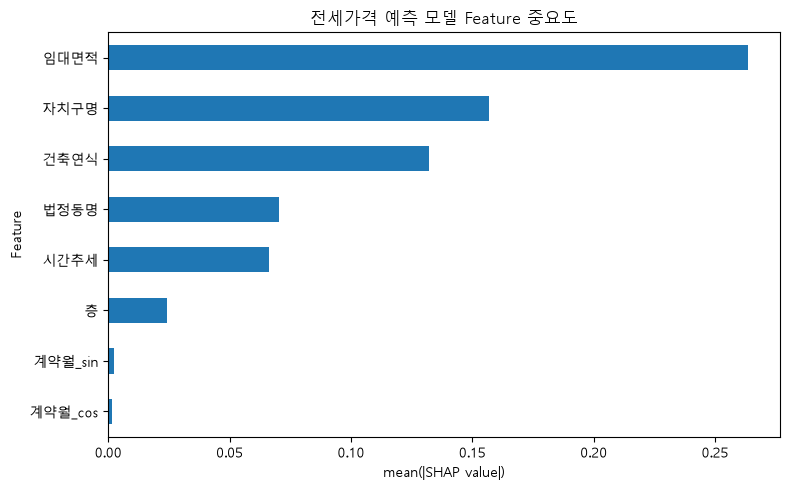

In [12]:
grouped_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title(
    "전세가격 예측 모델 Feature 중요도"
)

plt.xlabel(
    "mean(|SHAP value|)"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

### 전세 모델 Feature 중요도 해석

SHAP 분석 결과, 전세가격 예측에 가장 큰 영향을 미친 변수는
전용면적(임대면적)으로 나타났다.

그 다음으로 자치구, 건축연식, 법정동, 시간추세 순으로
높은 중요도를 보였다.

#### 주요 결과

1. **임대면적**
   - 전체 Feature 중 가장 높은 중요도를 보였다.
   - 전용면적이 전세보증금 결정에 핵심적인 변수임을 의미한다.
   - 이는 통계분석에서 전용면적과 전세보증금 사이에
     비교적 강한 양의 상관관계가 나타난 결과와도 일치한다.

2. **지역 정보**
   - 자치구와 법정동 모두 높은 중요도를 보였다.
   - 서울 내에서도 입지에 따라 전세가격 구조가 크게 다름을 보여준다.
   - 특히 자치구는 건축연식보다도 높은 중요도를 나타냈다.

3. **건축연식**
   - 세 번째로 높은 중요도를 보였다.
   - 통계분석에서 지역과 면적 등을 통제한 이후에도
     건축연식과 전세가격의 유의한 관계가 확인된 결과와 일관된다.

4. **시간추세**
   - 계약 시점 역시 일정 수준의 중요도를 나타냈다.
   - 이는 2023~2025년 사이의 시장 가격 변화가
     모델 예측에 반영되고 있음을 의미한다.

5. **층 및 계절성**
   - 층의 영향은 상대적으로 작았으며,
     계약월의 주기적 계절성 변수는 매우 낮은 중요도를 보였다.

따라서 최종 모델은 단순히 면적만을 이용하는 것이 아니라
지역, 건축연식, 시장의 시간 변화 등을 함께 고려하여
전세가격을 예측하고 있는 것으로 해석할 수 있다.

단, SHAP Feature 중요도는 모델의 예측에 대한 기여도를 나타내며
해당 변수가 가격 변화의 직접적인 원인임을 의미하지 않는다.

In [13]:
jeonse_explain = X_shap.copy()

jeonse_explain["shap_임대면적"] = (
    grouped_shap_df["임대면적"].values
)

jeonse_explain["shap_건축연식"] = (
    grouped_shap_df["건축연식"].values
)

jeonse_explain["shap_시간추세"] = (
    grouped_shap_df["시간추세"].values
)

jeonse_explain.head()

,자치구명,법정동명,임대면적,building_age,층,time_idx,contract_month_sin,contract_month_cos,shap_임대면적,shap_건축연식,shap_시간추세
73986,구로구,구로동,79.970,38.0,13.0,30,-5.000000e-01,-8.660254e-01,0.059791,-0.169233,0.062533
95243,송파구,장지동,84.960,12.0,14.0,29,1.224647e-16,-1.000000e+00,0.263912,0.031451,0.060801
179915,동대문구,답십리동,24.270,6.0,10.0,26,1.000000e+00,6.123234e-17,-0.917245,0.344242,0.046243
192625,마포구,공덕동,59.959,14.0,1.0,25,8.660254e-01,5.000000e-01,0.004244,0.009954,0.071314
184486,중구,인현동2가,24.553,2.0,24.0,26,1.000000e+00,6.123234e-17,-0.940851,0.356087,0.034818


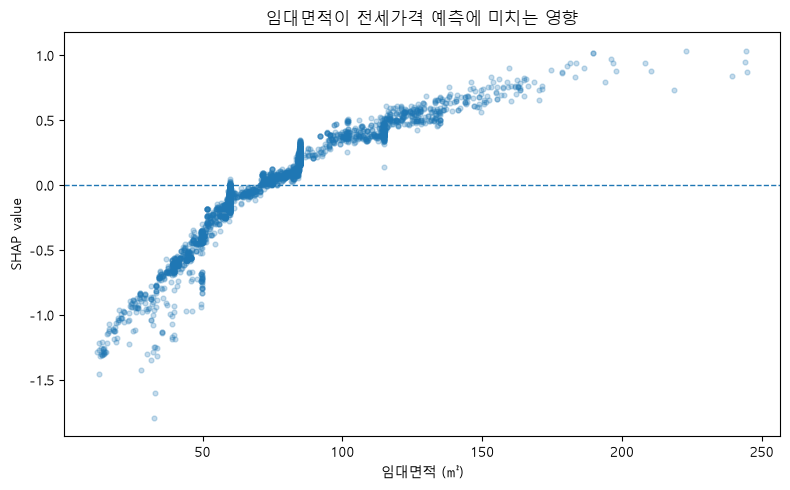

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    jeonse_explain["임대면적"],
    jeonse_explain["shap_임대면적"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("임대면적 (㎡)")
plt.ylabel("SHAP value")
plt.title("임대면적이 전세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 임대면적 SHAP 해석

임대면적의 SHAP 값을 확인한 결과,
면적이 증가할수록 전세가격 예측에 미치는 영향도 전반적으로 증가하였다.

작은 면적의 주택은 SHAP 값이 주로 음수로 나타나
전세가격 예측을 낮추는 방향으로 작용하였다.

반대로 면적이 커질수록 SHAP 값이 양수로 전환되어
전세가격 예측을 높이는 방향으로 작용하였다.

특히 약 60~80㎡ 부근을 지나면서
SHAP 값이 음수에서 양수로 전환되는 패턴이 관찰되었다.

또한 대형 면적으로 갈수록 예측가격을 높이는 효과는 유지되지만
증가폭은 점차 완만해지는 비선형적인 형태가 나타났다.

이는 전세가격과 면적의 관계가 단순한 직선 관계가 아니라
면적 구간에 따라 영향 정도가 달라질 수 있음을 보여준다.

본 SHAP 값은 로그 전세가격 예측에 대한 기여도를 의미하며,
면적이 가격 변화의 직접적인 원인임을 의미하지 않는다.

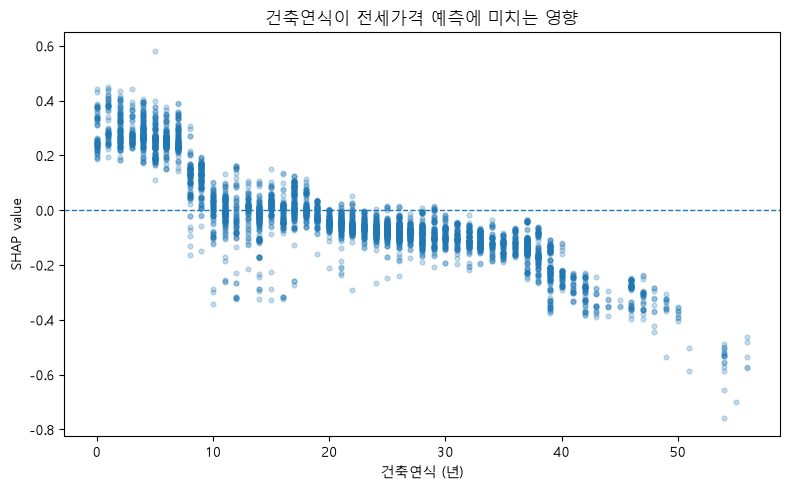

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    jeonse_explain["building_age"],
    jeonse_explain["shap_건축연식"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("건축연식 (년)")
plt.ylabel("SHAP value")
plt.title("건축연식이 전세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 건축연식 SHAP 해석

건축연식의 SHAP 값을 확인한 결과,
건축연식이 증가할수록 전세가격 예측에 미치는 영향이
전반적으로 감소하는 패턴이 나타났다.

신축에 가까운 아파트는 SHAP 값이 주로 양수로 나타나
전세가격 예측을 높이는 방향으로 작용하였다.

반면 건축연식이 증가하면서 SHAP 값은 점차 0에 가까워졌으며,
오래된 아파트에서는 주로 음수 값을 보여
전세가격 예측을 낮추는 방향으로 작용하였다.

특히 20년 이상 된 아파트에서는
음의 SHAP 값이 보다 뚜렷하게 나타났고,
40년 이상 구간에서는 가격 예측을 낮추는 영향이
더 강해지는 경향이 관찰되었다.

이는 통계분석에서 건축연식과 전세가격 사이에
음의 관계가 나타난 결과와 일관된다.

다만 SHAP 값은 모델의 예측 기여도를 나타내는 것으로,
건축연식 자체가 전세가격 하락의 직접적인 원인임을 의미하지 않는다.

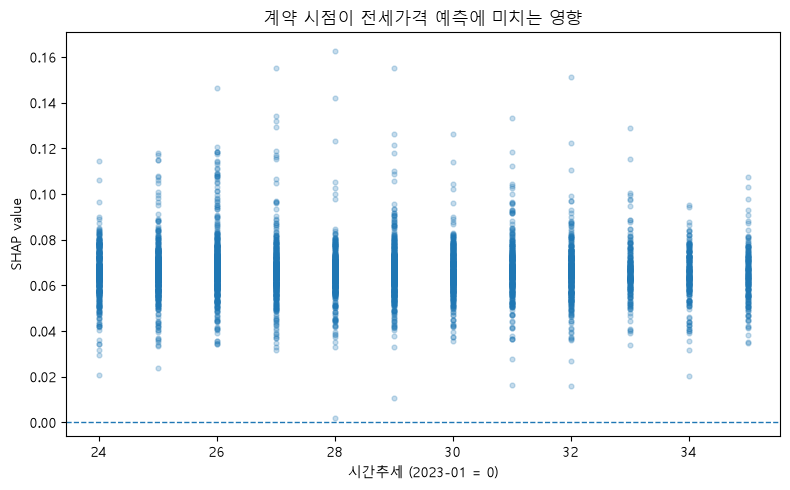

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    jeonse_explain["time_idx"],
    jeonse_explain["shap_시간추세"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("시간추세 (2023-01 = 0)")
plt.ylabel("SHAP value")
plt.title("계약 시점이 전세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 시간추세 SHAP 해석

2025년 Test 데이터에서 시간추세 Feature의 SHAP 값은
대부분 양수로 나타났다.

이는 2025년 계약 시점이 모델의 기준 예측값과 비교했을 때
전세가격 예측을 높이는 방향으로 기여하고 있음을 보여준다.

그러나 2025년 1월부터 12월까지 SHAP 값이
시간에 따라 뚜렷하게 증가하거나 감소하는 패턴은 나타나지 않았다.

또한 본 모델은 2023~2024년 데이터를 학습하고
2025년 데이터를 예측하도록 구성되어 있다.

XGBoost와 같은 Tree 기반 모델은
학습 데이터의 시간 범위를 벗어난 값에 대해
선형적인 미래 추세를 외삽하는 데 한계가 있다.

따라서 본 결과는 2025년이라는 시점이
가격 예측에 일정한 양의 기여를 했다는 정도로 해석하며,
2025년 내부의 지속적인 가격 상승 또는 하락 추세를
의미하는 것으로 해석하지 않는다.

In [17]:
jeonse_explain["shap_자치구"] = (
    grouped_shap_df["자치구명"].values
)

district_shap = (
    jeonse_explain
    .groupby("자치구명")
    .agg(
        mean_shap=("shap_자치구", "mean"),
        median_shap=("shap_자치구", "median"),
        count=("shap_자치구", "size")
    )
    .sort_values(
        "mean_shap",
        ascending=False
    )
)

district_shap

,mean_shap,median_shap,count
자치구명,,,
강남구,0.399171,0.414260,396
서초구,0.311387,0.317282,371
용산구,0.129962,0.127106,110
성동구,0.123228,0.120485,230
광진구,0.117604,0.125979,95
마포구,0.100791,0.105065,245
송파구,0.087221,0.089119,429
중구,0.053548,0.057331,76
동작구,0.030875,0.034537,198


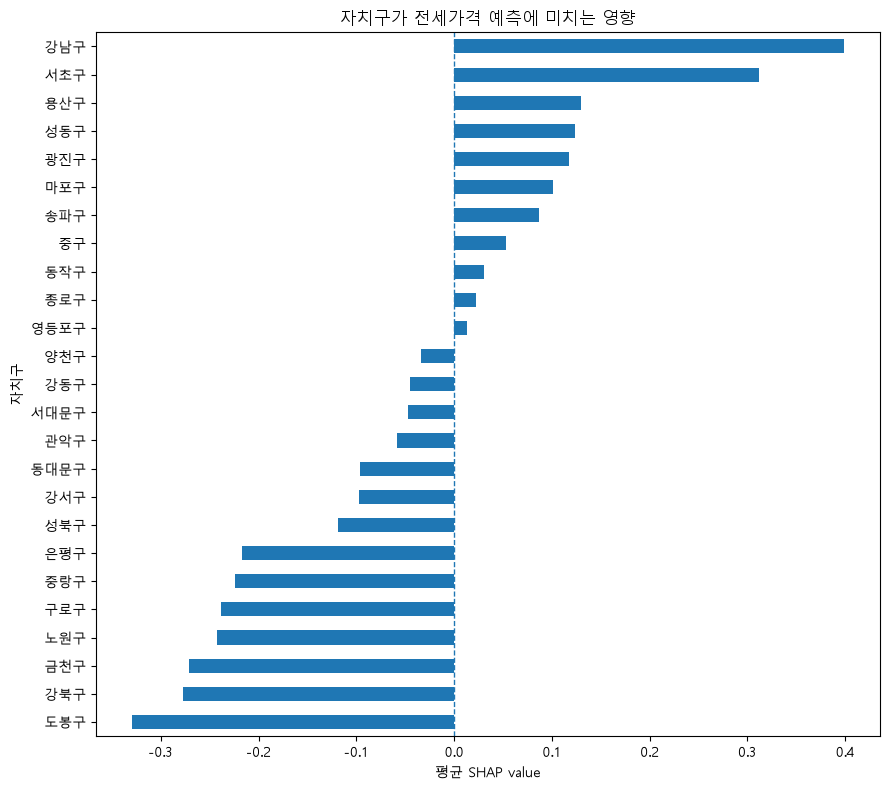

In [18]:
district_shap[
    "mean_shap"
].sort_values().plot(
    kind="barh",
    figsize=(9, 8)
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("평균 SHAP value")
plt.ylabel("자치구")
plt.title(
    "자치구가 전세가격 예측에 미치는 영향"
)

plt.tight_layout()
plt.show()

### 자치구 SHAP 해석

자치구별 SHAP 값을 비교한 결과,
지역에 따라 전세가격 예측에 미치는 영향이 뚜렷하게 구분되었다.

강남구와 서초구는 가장 큰 양의 SHAP 값을 보여
다른 주택 특성이 동일하더라도 모델의 전세가격 예측을
높이는 방향으로 강하게 작용하였다.

용산구와 성동구 역시 비교적 높은 양의 영향을 보였으며,
광진구, 마포구, 송파구 등도 전세가격 예측을
높이는 방향으로 나타났다.

반대로 도봉구, 강북구, 금천구, 노원구, 구로구 등은
음의 SHAP 값이 크게 나타나
전세가격 예측을 낮추는 방향으로 작용하였다.

이러한 결과는 EDA에서 확인한 자치구별
단위면적당 전세가격 차이와 전반적으로 일관된 패턴이다.

또한 통계분석에서 자치구별 가격 차이의 효과크기가
크게 나타난 결과와도 연결된다.

따라서 최종 XGBoost 모델 역시
서울 내 지역적 가격 구조를 중요한 예측 정보로
학습하고 있는 것으로 해석할 수 있다.

단, SHAP 값은 다른 Feature들과 함께 구성된 모델 내부의
예측 기여도를 나타내므로 이를 특정 지역 자체의
인과적 가격 프리미엄으로 해석하지 않는다.

In [19]:
jeonse_explain["shap_법정동"] = (
    grouped_shap_df["법정동명"].values
)

In [20]:
dong_shap = (
    jeonse_explain
    .groupby(
        ["자치구명", "법정동명"]
    )
    .agg(
        mean_shap=("shap_법정동", "mean"),
        count=("shap_법정동", "size")
    )
    .reset_index()
)

# 표본이 너무 적은 동은 제외
dong_shap_filtered = dong_shap[
    dong_shap["count"] >= 20
].copy()

In [21]:
dong_shap_filtered.sort_values(
    "mean_shap",
    ascending=False
).head(10)

,자치구명,법정동명,mean_shap,count
166,송파구,잠실동,0.272460,75
169,양천구,목동,0.222649,95
132,성동구,성수동1가,0.208682,29
164,송파구,신천동,0.196244,50
117,서초구,반포동,0.167292,77
47,구로구,신도림동,0.166813,24
188,영등포구,여의도동,0.135051,34
2,강남구,대치동,0.119582,68
123,서초구,잠원동,0.104919,97
157,송파구,가락동,0.099514,55


In [22]:
dong_shap_filtered.sort_values(
    "mean_shap"
).head(10)

,자치구명,법정동명,mean_shap,count
14,강동구,강일동,-0.360786,59
170,양천구,신월동,-0.242034,36
5,강남구,세곡동,-0.236927,20
114,서대문구,홍은동,-0.206564,29
89,마포구,상암동,-0.205958,22
122,서초구,우면동,-0.186815,30
12,강남구,자곡동,-0.177413,22
224,은평구,진관동,-0.167980,57
167,송파구,장지동,-0.136988,54
19,강동구,상일동,-0.136635,67


### 법정동 SHAP 해석

법정동별 SHAP 값을 분석한 결과,
자치구보다 세부적인 지역 수준에서도
전세가격 예측에 차이가 존재하는 것으로 나타났다.

가격 예측을 높이는 방향의 법정동으로는
잠실동, 목동, 성수동1가, 신천동, 반포동,
여의도동, 대치동, 잠원동 등이 나타났다.

반대로 강일동, 신월동, 세곡동, 홍은동,
상암동, 우면동, 자곡동, 진관동 등은
전세가격 예측을 낮추는 방향의 SHAP 값을 보였다.

특히 같은 자치구 내부에서도 법정동에 따라
SHAP 값의 방향과 크기가 크게 달라지는 사례가 확인되었다.

예를 들어 강남구에서는 대치동이 양의 영향을 보인 반면
세곡동과 자곡동은 음의 영향을 보였으며,
서초구에서도 반포동과 잠원동은 양의 영향을,
우면동은 음의 영향을 나타냈다.

이는 서울의 전세가격 구조를 설명할 때
자치구 수준의 지역 정보만으로는 충분하지 않으며,
보다 세부적인 입지 정보도 중요한 역할을 한다는 것을 보여준다.

단, 법정동 SHAP 값은 자치구, 면적, 건축연식 등
다른 Feature의 기여도와 함께 최종 예측을 구성한다.

따라서 음의 법정동 SHAP 값을 해당 지역의
절대적인 저가 지역이라는 의미로 해석해서는 안 된다.

In [23]:
dong_shap_filtered = dong_shap[
    dong_shap["count"] >= 30
].copy()

top_dong = (
    dong_shap_filtered
    .sort_values("mean_shap", ascending=False)
    .head(10)
)

bottom_dong = (
    dong_shap_filtered
    .sort_values("mean_shap")
    .head(10)
)

display(top_dong)
display(bottom_dong)

,자치구명,법정동명,mean_shap,count
166,송파구,잠실동,0.272460,75
169,양천구,목동,0.222649,95
164,송파구,신천동,0.196244,50
117,서초구,반포동,0.167292,77
188,영등포구,여의도동,0.135051,34
2,강남구,대치동,0.119582,68
123,서초구,잠원동,0.104919,97
157,송파구,가락동,0.099514,55
205,용산구,이촌동,0.092367,44
135,성동구,옥수동,0.080092,31


,자치구명,법정동명,mean_shap,count
14,강동구,강일동,-0.360786,59
170,양천구,신월동,-0.242034,36
122,서초구,우면동,-0.186815,30
224,은평구,진관동,-0.167980,57
167,송파구,장지동,-0.136988,54
19,강동구,상일동,-0.136635,67
36,관악구,신림동,-0.136350,30
256,중랑구,신내동,-0.125384,33
158,송파구,거여동,-0.120649,51
153,성북구,장위동,-0.112276,30


# 월세 모델 SHAP 분석

최종 월세 예측 모델인 XGBoost에 대해 SHAP 분석을 수행한다.

특히 다음 내용을 확인한다.

- 보증금이 월세 예측에 얼마나 중요한가?
- 보증금이 증가할수록 월세 예측을 낮추는 방향으로 작용하는가?
- 지역, 면적, 건축연식은 월세가격 예측에 어떤 영향을 미치는가?
- 통계분석 H5에서 확인한 보증금-월세 관계와
  머신러닝 모델의 예측 패턴이 일치하는가?

전체 Test 데이터 대신 대표 표본 5,000건을 사용하여 분석한다.

In [24]:
monthly_model = joblib.load(
    MODEL_DIR / "monthly_xgboost.joblib"
)

monthly_test = pd.read_csv(
    MODEL_DATA_DIR / "monthly_test.csv",
    parse_dates=["contract_date"]
)

print("Monthly Test:", monthly_test.shape)
print("Model:", type(monthly_model))

Monthly Test: (183778, 12)
Model: <class 'sklearn.pipeline.Pipeline'>


In [25]:
monthly_features = [
    "자치구명",
    "법정동명",
    "임대면적",
    "building_age",
    "층",
    "log_deposit",
    "time_idx",
    "contract_month_sin",
    "contract_month_cos"
]

In [26]:
X_monthly_shap = monthly_test[
    monthly_features
].sample(
    n=5000,
    random_state=42
)

print(
    "SHAP sample:",
    X_monthly_shap.shape
)

SHAP sample: (5000, 9)


In [27]:
monthly_preprocessor = monthly_model.named_steps[
    "preprocessor"
]

monthly_xgb_estimator = monthly_model.named_steps[
    "model"
]

X_monthly_transformed = monthly_preprocessor.transform(
    X_monthly_shap
)

monthly_feature_names = (
    monthly_preprocessor
    .get_feature_names_out()
)

print(
    "변환 데이터:",
    X_monthly_transformed.shape
)

print(
    "Feature 개수:",
    len(monthly_feature_names)
)

변환 데이터: (5000, 360)
Feature 개수: 360


## 월세 Feature 중요도

월세 XGBoost 모델에 대해 SHAP 값을 계산하고,
각 Feature가 월세 예측에 얼마나 크게 기여하는지 확인한다.

월세 모델은 `log(월세)`를 Target으로 학습했기 때문에
SHAP 값 역시 로그 월세 예측값에 대한 기여도를 의미한다.

In [28]:
monthly_explainer = shap.TreeExplainer(
    monthly_xgb_estimator
)

monthly_shap_values = monthly_explainer.shap_values(
    X_monthly_transformed
)

print(
    "SHAP values shape:",
    monthly_shap_values.shape
)

SHAP values shape: (5000, 360)


In [29]:
monthly_feature_names = np.array(
    monthly_feature_names
)

monthly_feature_groups = {
    "자치구명": np.where(
        np.char.startswith(
            monthly_feature_names.astype(str),
            "cat__자치구명_"
        )
    )[0],

    "법정동명": np.where(
        np.char.startswith(
            monthly_feature_names.astype(str),
            "cat__법정동명_"
        )
    )[0],

    "임대면적": np.where(
        monthly_feature_names == "num__임대면적"
    )[0],

    "건축연식": np.where(
        monthly_feature_names == "num__building_age"
    )[0],

    "층": np.where(
        monthly_feature_names == "num__층"
    )[0],

    "보증금": np.where(
        monthly_feature_names == "num__log_deposit"
    )[0],

    "시간추세": np.where(
        monthly_feature_names == "num__time_idx"
    )[0],

    "계약월_sin": np.where(
        monthly_feature_names
        == "num__contract_month_sin"
    )[0],

    "계약월_cos": np.where(
        monthly_feature_names
        == "num__contract_month_cos"
    )[0]
}

In [30]:
monthly_grouped_shap = {}

for group_name, indices in monthly_feature_groups.items():
    monthly_grouped_shap[group_name] = (
        monthly_shap_values[:, indices]
        .sum(axis=1)
    )

monthly_grouped_shap_df = pd.DataFrame(
    monthly_grouped_shap
)

monthly_grouped_importance = (
    monthly_grouped_shap_df
    .abs()
    .mean()
    .sort_values(ascending=False)
)

monthly_grouped_importance

임대면적       0.550374
보증금        0.393125
자치구명       0.186252
건축연식       0.167783
시간추세       0.094006
법정동명       0.090306
층          0.033912
계약월_sin    0.002360
계약월_cos    0.001820
dtype: float32

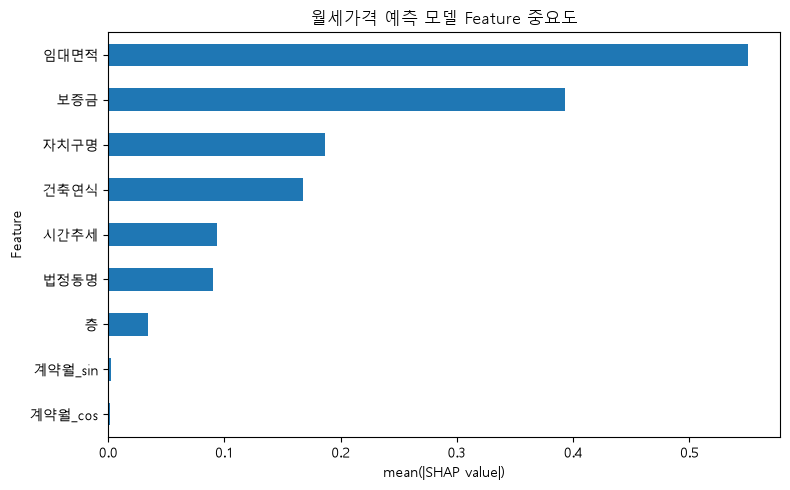

In [31]:
monthly_grouped_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title(
    "월세가격 예측 모델 Feature 중요도"
)

plt.xlabel(
    "mean(|SHAP value|)"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

### 월세 모델 Feature 중요도 해석

SHAP 분석 결과, 월세가격 예측에 가장 큰 영향을 미친 변수는
임대면적으로 나타났다.

두 번째로 높은 중요도를 보인 변수는 보증금으로,
자치구, 건축연식, 법정동 등 지역 및 주택 특성보다도
높은 예측 기여도를 나타냈다.

이는 월세 계약에서 보증금이 월세 수준을 결정하는 데
중요한 정보로 활용되고 있음을 보여준다.

그 다음으로 자치구, 건축연식, 시간추세,
법정동 순으로 높은 중요도가 나타났다.

반면 층의 영향은 상대적으로 작았으며,
계약월을 표현한 계절성 변수의 중요도는 매우 낮게 나타났다.

다만 현재 Feature 중요도는 각 변수가 예측에 미치는 영향의
크기만을 나타내며, 영향의 방향은 보여주지 않는다.

따라서 다음 단계에서는 보증금의 SHAP 값을 직접 분석하여
보증금 증가가 월세 예측을 높이는지 낮추는지 확인한다.

In [32]:
monthly_explain = X_monthly_shap.copy()

monthly_explain["shap_보증금"] = (
    monthly_grouped_shap_df["보증금"].values
)

monthly_explain["보증금(만원)"] = np.expm1(
    monthly_explain["log_deposit"]
)

monthly_explain[
    [
        "보증금(만원)",
        "log_deposit",
        "shap_보증금"
    ]
].head()

,보증금(만원),log_deposit,shap_보증금
49395,53000.0,10.878066,-0.648348
6662,5976.0,8.695674,-0.270093
27071,500.0,6.216606,0.477242
49243,10000.0,9.210440,0.442223
78114,15000.0,9.615872,0.303260


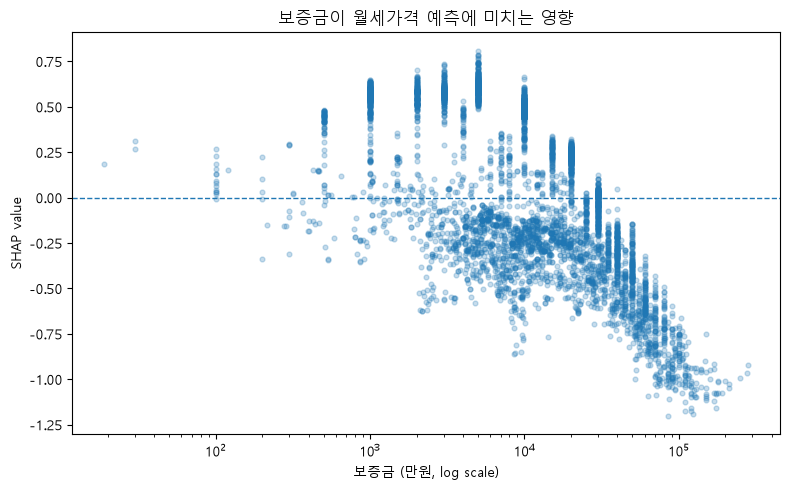

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_explain["보증금(만원)"],
    monthly_explain["shap_보증금"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xscale("log")

plt.xlabel("보증금 (만원, log scale)")
plt.ylabel("SHAP value")
plt.title("보증금이 월세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 보증금 SHAP 해석

보증금의 SHAP 값을 분석한 결과,
보증금이 증가할수록 월세가격 예측에 미치는 영향이
전반적으로 감소하는 패턴이 나타났다.

낮은 보증금 구간에서는 SHAP 값이 0 또는 양수인 사례가 상대적으로 많아
월세가격 예측을 높이는 방향으로 작용하였다.

반대로 보증금이 높은 계약에서는 SHAP 값이 대부분 음수로 나타나
월세가격 예측을 낮추는 방향으로 작용하였다.

이는 통계분석 H5에서 자치구, 면적, 건축연식, 층, 계약연도를 통제했을 때
보증금이 증가할수록 월세가 감소하는 관계가 나타난 결과와
전반적으로 일치한다.

다만 중간 보증금 구간에서는 양의 SHAP 값도 일부 관찰되었다.
이는 월세가격이 보증금 하나만으로 결정되는 것이 아니라
면적, 지역, 건축연식 등 다른 Feature와의 상호작용에 영향을 받기 때문이다.

따라서 본 결과는 보증금과 월세 사이에
전반적인 음의 관계가 존재함을 보여주지만,
모든 계약에서 동일한 크기의 관계가 나타난다는 의미는 아니다.

In [34]:
monthly_explain["shap_임대면적"] = (
    monthly_grouped_shap_df["임대면적"].values
)

monthly_explain["shap_건축연식"] = (
    monthly_grouped_shap_df["건축연식"].values
)

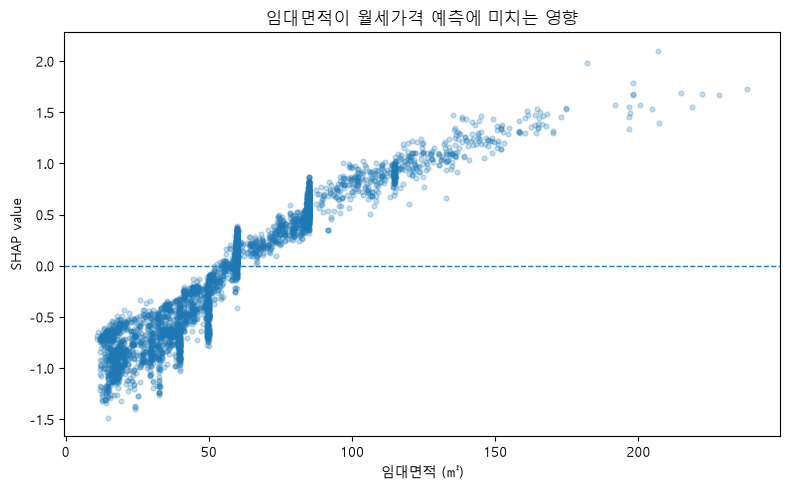

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_explain["임대면적"],
    monthly_explain["shap_임대면적"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("임대면적 (㎡)")
plt.ylabel("SHAP value")
plt.title("임대면적이 월세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 임대면적 SHAP 해석

월세 모델에서도 임대면적은 전체 Feature 중
가장 높은 중요도를 보였다.

SHAP 값을 확인한 결과,
임대면적이 증가할수록 월세가격 예측에 미치는 영향이
전반적으로 증가하는 패턴이 나타났다.

소형 면적에서는 SHAP 값이 주로 음수로 나타나
월세가격 예측을 낮추는 방향으로 작용하였다.

반면 약 50~60㎡ 부근을 지나면서 SHAP 값이
점차 양수로 전환되었으며,
면적이 커질수록 월세가격 예측을 높이는 영향도 증가하였다.

대형 아파트에서는 양의 SHAP 값이 더욱 크게 나타나
면적이 월세가격 예측에 매우 중요한 변수임을 확인할 수 있었다.

또한 영향의 증가폭이 모든 면적 구간에서 동일하지 않아
면적과 월세가격 사이에도 비선형적인 관계가 존재하는 것으로 보인다.

본 SHAP 값은 로그 월세가격 예측에 대한 기여도를 의미하며,
면적 자체가 월세 상승의 직접적인 원인임을 의미하지 않는다.

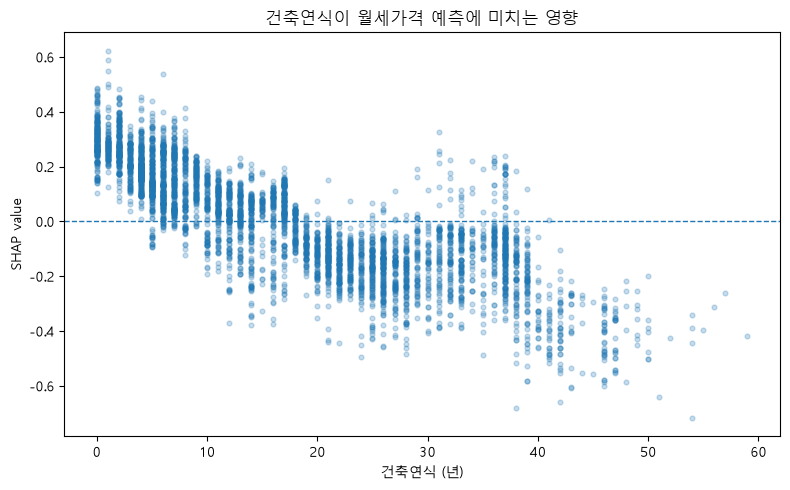

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_explain["building_age"],
    monthly_explain["shap_건축연식"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("건축연식 (년)")
plt.ylabel("SHAP value")
plt.title("건축연식이 월세가격 예측에 미치는 영향")

plt.tight_layout()
plt.show()

### 건축연식 SHAP 해석

건축연식이 증가할수록 월세가격 예측에 미치는 영향은
전반적으로 감소하는 패턴을 보였다.

신축에 가까운 아파트에서는 SHAP 값이 주로 양수로 나타나
월세가격 예측을 높이는 방향으로 작용하였다.

건축연식이 증가하면서 SHAP 값은 점차 감소하였으며,
약 15~20년 부근부터 0 또는 음수 영역의 비중이 증가하였다.

오래된 아파트에서는 음의 SHAP 값이 주로 나타났으며,
특히 40년 이상 구간에서는 월세가격 예측을
낮추는 영향이 더욱 뚜렷하게 관찰되었다.

이는 전세 모델에서 확인한 건축연식의 영향과도
전반적으로 일관된 패턴이다.

따라서 건축연식은 전세와 월세 모두에서
가격 예측에 중요한 주택 특성으로 활용되고 있음을 확인하였다.

단, 본 결과 역시 모델의 예측 기여도를 나타내는 것으로
건축연식과 월세가격 사이의 직접적인 인과관계를 의미하지 않는다.

# Model Explainability 종합 결론

최종 XGBoost 모델에 SHAP을 적용하여
전세와 월세가격 예측에 각 Feature가 어떤 방식으로 기여하는지 분석하였다.

## 전세가격 모델

전세가격 예측에서 가장 중요한 변수는
임대면적으로 나타났다.

그 다음으로 자치구, 건축연식, 법정동,
시간추세 순으로 높은 중요도를 보였다.

임대면적은 증가할수록 전세가격 예측을 높이는 방향으로 작용하였고,
건축연식은 오래될수록 가격 예측을 낮추는 패턴을 보였다.

지역 변수 역시 강한 영향을 보였으며,
강남구와 서초구 등은 가격 예측을 높이는 방향으로,
도봉구와 강북구 등은 낮추는 방향으로 나타났다.

자치구 내부에서도 법정동에 따라
예측 기여도가 달라지는 패턴이 확인되어
세부적인 입지 정보 역시 중요한 것으로 나타났다.

## 월세가격 모델

월세가격 예측에서도 가장 중요한 변수는 임대면적이었으며,
두 번째로 보증금이 높은 중요도를 보였다.

보증금의 SHAP 값을 분석한 결과,
보증금이 증가할수록 월세가격 예측을 낮추는
전반적인 음의 관계가 확인되었다.

이는 통계분석에서 다른 조건을 통제했을 때
보증금 1% 증가 시 월세가 약 0.257% 감소하는
관계가 나타난 결과와 일관된다.

월세 모델에서도 면적이 증가할수록 가격 예측은 높아지고,
건축연식이 증가할수록 가격 예측은 낮아지는
패턴이 관찰되었다.

## 분석 과정의 일관성

이번 프로젝트에서는 동일한 현상을
EDA, 통계분석, 머신러닝, SHAP의 여러 단계에서 반복적으로 확인하였다.

- 지역별 전세가격 차이
  → EDA에서 관찰
  → Kruskal-Wallis 검정에서 통계적으로 확인
  → XGBoost에서 높은 Feature 중요도 확인
  → SHAP에서 지역별 예측 방향 확인

- 건축연식과 가격
  → EDA에서 신축 프리미엄 관찰
  → 상관분석 및 다중회귀에서 음의 관계 확인
  → SHAP에서도 오래될수록 가격 예측을 낮추는 패턴 확인

- 보증금과 월세
  → 전체 단순 상관에서는 약한 양의 관계
  → 지역과 면적을 고려하면 음의 관계
  → 다중회귀에서 보증금 증가에 따른 월세 감소 확인
  → XGBoost SHAP에서도 동일한 방향의 패턴 확인

이를 통해 단순한 상관관계만으로 결론을 내리지 않고,
통계적 통제와 머신러닝 모델 해석을 함께 사용하는 것이
부동산 임대가격 구조를 이해하는 데 중요함을 확인하였다.

다만 SHAP은 모델의 예측 근거를 설명하는 방법이며,
각 Feature가 가격을 직접적으로 변화시키는
인과관계를 증명하는 것은 아니다.